In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time




In [2]:
A = np.array([[3 , -0.1 , -0.2],
              [0.1 , 7 , -0.3],
              [0.3 , -0.2 , 10]])

b = np.array([7.85, -19.3, 71.4])

x0 = np.zeros_like(b)





In [6]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    start_time = time.perf_counter()

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float).copy()

    n = len(b)
    errors = []


    for k in range(max_iterations):
        x_new = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))        
            s2 = sum(A[i][j] * x[j]     for j in range(i + 1, n))  
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            duration = time.perf_counter() - start_time
            return x_new, k + 1, duration, np.array(errors)

        x = x_new

    raise RuntimeError(f"Gauss-Seidel method did not converge after {max_iterations} iterations.")

In [7]:
def jacobi(A, b, x0, tol, max_iterations):
    start_time = time.perf_counter()
    n = len(b)

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float).copy()

    errors = []

    for k in range(max_iterations):
        x_new = np.zeros_like(x)

        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            duration = time.perf_counter() - start_time
            return x_new, (k + 1), duration, np.array(errors)

        x = x_new

    raise RuntimeError(f"Jacobi method did not converge after {max_iterations} iterations.")

Initial Guess: x = [0. 0. 0.]
Tolerance = 0.001

Jacobi:
Iterations: 4
Time: 0.0008084792643785477

Gauss-Seidel:
Iterations: 4
Time: 0.0003694724291563034


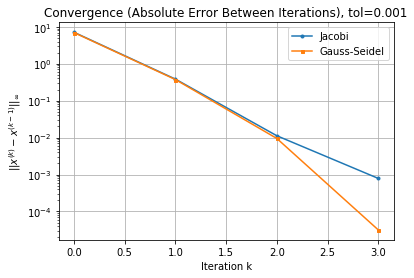

Initial Guess: x = [0. 0. 0.]
Tolerance = 1e-06

Jacobi:
Iterations: 7
Time: 0.0009728968143463135

Gauss-Seidel:
Iterations: 5
Time: 0.0001823902130126953


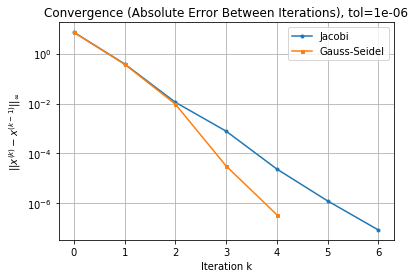

Initial Guess: x = [0. 0. 0.]
Tolerance = 1e-09

Jacobi:
Iterations: 9
Time: 0.0009537786245346069

Gauss-Seidel:
Iterations: 7
Time: 0.00025492534041404724


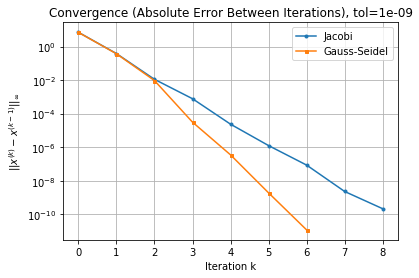

In [27]:
tols = [1e-3, 1e-6, 1e-9]
max_iterations = 100
x0 = np.zeros_like(b, dtype=float)

for tol in tols:
    xJ, itJ, timeJ, errJ = jacobi(A, b, x0, tol, max_iterations)
    xG, itG, timeG, errG = gauss_seidel(A, b, x0, tol, max_iterations) 

    print(f"Tolerance = {tol}")
    print(f"\nJacobi:") 
    print(f"Iterations:", itJ)
    print(f"Time:", timeJ)
    print(f"\nGauss-Seidel:")
    print(f"Iterations:", itG)
    print(f"Time:", timeG)
    
    """
    When using the plt.plot function it makes it difficult to see a visual difference, I asked chatGPT 
    for ideas to help with this.
    To which it responded with the idea of a semi-log plot.
    
    """

    plt.figure()
    plt.semilogy(errJ, marker='o', markersize=3, label="Jacobi")
    plt.semilogy(errG, marker='s', markersize=3, label="Gauss-Seidel")
    plt.xlabel("Iteration k")
    plt.ylabel(r"$||x^{(k)} - x^{(k-1)}||_\infty$")
    plt.title(f"Convergence (Absolute Error Between Iterations), tol={tol}")
    plt.grid(True, which="Major")
    plt.legend()
    plt.show()

As the tolerence increases the number of Iterations it takes to converge also increases, This is supported by the number of Iterations seen in my plots for each tolerance. 